<a href="https://colab.research.google.com/github/soujoudgahgah/-DecodeLabs-Internship/blob/main/Project-2-AIrisClassifier/IrisNet_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-learn pandas numpy matplotlib seaborn

In [ ]:
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np


iris = load_iris()
X = iris.data
y = iris.target

print(f"Dataset Shape: {X.shape}")
print(f"Classes: {iris.target_names}")

Dataset Shape: (150, 4)
Classes: ['setosa' 'versicolor' 'virginica']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Training data: {X_train.shape}")
print(f"Testing data: {X_test.shape}")

Training data: (120, 4)
Testing data: (30, 4)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

print("Model training complete!")

Model training complete!



F1 Score: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



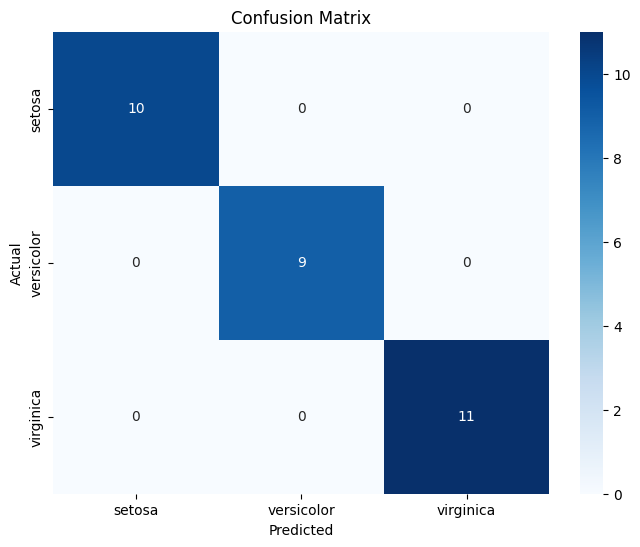

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


predictions = model.predict(X_test)


f1 = f1_score(y_test, predictions, average='weighted')
print(f"\nF1 Score: {f1:.4f}")


print("\nClassification Report:")
print(classification_report(y_test, predictions, target_names=iris.target_names))


cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names,
            cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

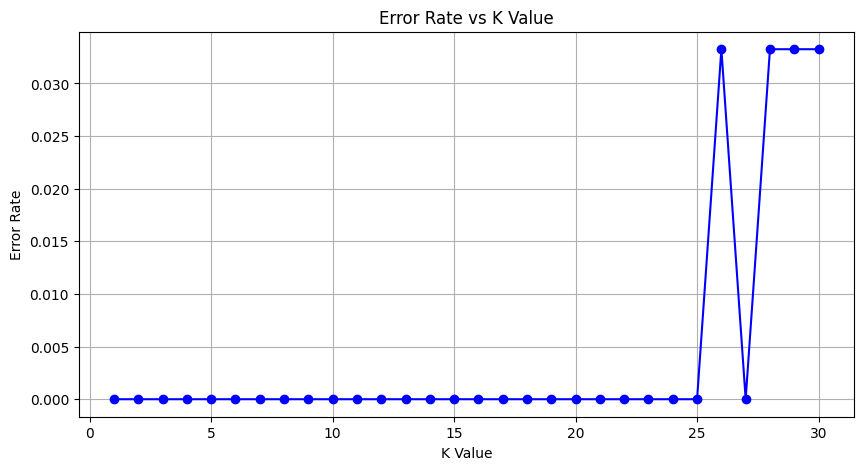

Best K value: 1


In [ ]:
error_rates = []

for k in range(1, 31):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    error_rates.append(1 - f1_score(y_test, preds, average='weighted'))

plt.figure(figsize=(10, 5))
plt.plot(range(1, 31), error_rates, marker='o', color='blue')
plt.title('Error Rate vs K Value')
plt.xlabel('K Value')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

best_k = error_rates.index(min(error_rates)) + 1
print(f"Best K value: {best_k}")